# Predicting gene networks/modules from data and mapping our genes onto them

The timing (Pre or Post) and cell type (e.g. T-cells, Innate_Lymphoid) can be changed and rerun for the appropriate combination of interest. Currently, it is set to Pre and T-cells.

In [4]:

library(muscat)
library(edgeR)
library(Seurat) # v 5.4.0
#devtools::install_github('smorabit/hdWGCNA', ref='dev')
library(hdWGCNA, lib.loc="/Users/hopekirby/.RLibraries/hdWGCNA")
library(SingleCellExperiment)
library(harmony) # install.packages('harmony')
library(DESeq2)


In [5]:
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-apple-darwin20
Running under: macOS Ventura 13.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.4-x86_64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.4-x86_64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.0

locale:
[1] C

time zone: America/Denver
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] DESeq2_1.44.0               SingleCellExperiment_1.26.0
 [3] SummarizedExperiment_1.34.0 Biobase_2.64.0             
 [5] MatrixGenerics_1.16.0       matrixStats_1.5.0          
 [7] hdWGCNA_0.4.09              GenomicRanges_1.56.2       
 [9] GenomeInfoDb_1.40.1         IRanges_2.38.1             
[11] S4Vectors_0.42.1            BiocGenerics_0.50.0        
[13] GeneOverlap_1.40.0          UCell_2.8.0                
[15] tidygraph_1.3.1             ggraph_

In [ ]:
.libPaths("/Users/hopekirby/.RLibraries/hdWGCNA")
#BiocManager::install(version = "3.19")

BiocManager::install(
  c(
    "AnnotationDbi",
    "BiocGenerics",
    "S4Vectors",
    "IRanges",
    "GenomicRanges"
  ),
  force = TRUE,
  update = TRUE
)

#

In [4]:
#sessionInfo()

## 1. Set up Bulk RNA-seq for WGCNA 
* Get the VST expression from DESeq2 and then run WGCNA on HPC

In [3]:
library(data.table)
library(here)
library(WGCNA)
enableWGCNAThreads(nThreads=3)
library(DESeq2)

Warning message:
"package 'data.table' was built under R version 4.4.1"

Adjuntando el paquete: 'data.table'


The following object is masked from 'package:SummarizedExperiment':

    shift


The following object is masked from 'package:GenomicRanges':

    shift


The following object is masked from 'package:IRanges':

    shift


The following objects are masked from 'package:S4Vectors':

    first, second


The following objects are masked from 'package:dplyr':

    between, first, last


Warning message:
"package 'here' was built under R version 4.4.1"
here() starts at /Users/hopekirby/Desktop/Clauset/NanoString-RNAseq-HGSOC



Allowing parallel execution with up to 3 working processes.


In [4]:
gene_list = c("IDO1", "CD40", "JAK2", "CTSS", "ALDOC", "TMUB2", "ID4", "ENO1", "EGR1", "OAS3", 
"RRM2", "GBP4", "AMOTL2", "ESYT3", "HCN3", "DDX11", "GPR173", "CLK2", "CDKL2", "SHROOM1", "CD274")
length(gene_list)

[1] 21

In [ ]:
# bulk RNA-seq data -- raw counts so can do VST
bulk_adzib <- as.data.frame(fread(here("../../data/counts/Adzibolosu_str_gtf_genes.txt")))
bulk_ega <- as.data.frame(fread(here("../../data/counts/EGA_str_gtf_genes.txt")))
bulk_matched <- as.data.frame(fread(here("../../data/Matched/RNAMatch4.18_str_gtf_genes.txt")))
dim(bulk_adzib)
dim(bulk_ega)
dim(bulk_matched)

bulk_adzib[1:4,1:20]
bulk_ega[1:4,1:20]
bulk_matched[1:4,1:20]


In [ ]:
# combine based on gene id alone
identical(bulk_adzib$Geneid, bulk_ega$Geneid)
identical(bulk_adzib$Geneid, bulk_matched$Geneid)
length(setdiff(gene_list, bulk_adzib$Geneid))


bulk_full = base::merge(bulk_adzib[,grepl("Geneid|.bam", colnames(bulk_adzib))],
	bulk_matched[,grepl("Geneid|.bam", colnames(bulk_matched))], by="Geneid")
bulk_full = base::merge(bulk_full,
	bulk_ega[,grepl("Geneid|.bam", colnames(bulk_ega))], by="Geneid")
dim(bulk_full)

full_gene_names <- bulk_full$Geneid
bulk_full <- as.matrix(bulk_full[,-1])
rownames(bulk_full) <- full_gene_names
bulk_full[1:2,1:10]
dim(bulk_full)

rm(bulk_adzib, bulk_ega, bulk_matched)
gc()

# combine based on pre vs post

[1] TRUE

[1] TRUE

[1] 0

[1] 49771   191

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam
A1BG,372,530,210,151,66,66,148,171,243,164
A1BG-AS1,120,128,65,64,22,18,41,36,81,37


[1] 49771   190

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,4985495,266.3,8597442,459.2,NA,6842505,365.5
Vcells,13558521,103.5,37692089,287.6,16384,36317025,277.1


In [ ]:
# Normalize Bulk Data with DESeq2 and do VST
# (removes impacts from depth while stabilizing variance)
dds <- DESeqDataSetFromMatrix(
  countData = bulk_full,   # genes × samples
  colData   = data.frame(row.names = colnames(bulk_full)),
  design    = ~ 1
)

dds <- estimateSizeFactors(dds)
vsd <- vst(dds, blind = TRUE)

bulk_expr <- assay(vsd)  # genes × samples

datExpr_bulk <- t(bulk_expr)  # samples × genes
saveRDS(datExpr_bulk, "../results/WGCNA_Bulk_VST_data.rds")


#### Prepare to split into Pre and Post

In [ ]:
# read in the metadata 
Adzib_meta <- fread("../../data/meta/Adzibolosu_metadata_09.11.24.txt")
new_colnames = c()
for (og_name in colnames(RNA_norm_matrix)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, Adzib_meta[Adzib_meta$SRR == srr,]$Name[1])
    }
new_colnames

In [ ]:
# all relevant samples to keep for L2FC have the Final_Bool of Y (or Backup)
ega_samps$Name <- paste0(ega_samps$Patient, "_", ega_samps$Timing)
ega_samps[ega_samps$Final_Bool == "Backup",]$Name <- paste0(ega_samps[ega_samps$Final_Bool == "Backup",]$Name, "_Backup")
ega_samps[ega_samps$Final_Bool == "Extra",]$Name <- paste0(ega_samps[ega_samps$Final_Bool == "Extra",]$Name, "_Extra")
ega_samps_bulk = ega_samps[ega_samps$Assay == "Bulk" & ega_samps$Final_Bool %in% c("Y", "Backup", "Extra"),]
ega_samps_bulk[1:4,]

In [ ]:
# only keep the relevant part of the names
new_colnames = c()
for (og_name in colnames(RNA_norm_matrix_ega)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, srr)
    }
colnames(RNA_norm_matrix_ega) <- new_colnames

## Single-cell Data

### 1. Read in Data and convert to Seurat object

In [ ]:
# SCE object for UMAP
sce <- readRDS("../../data/final_counts/GSE165897_HGSOC_SCEobject.rds")
dim(sce)
# PFS information
ega_samps <- readxl::read_excel("../../data/meta/EGA_Final_Samples.xlsx")
sce

[1] 32847 51786

New names:
* `` -> `...27`
* `` -> `...28`
* `` -> `...29`


class: SingleCellExperiment 
dim: 32847 51786 
metadata(0):
assays(1): counts
rownames(32847): RP11-34P13.7 RP11-34P13.8 ... MT-TT MT-TP
rowData names(0):
colnames(51786): AAACCTGCAGGTTTCA-EOC372_pPer
  AAACCTGGTCCGAATT-EOC372_pPer ... TTTGTCACATTGGGCC-EOC443_pOme
  TTTGTCAGTAAGGATT-EOC443_pOme
colData names(10): cell sample ... nFeature_RNA percent.mt
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [7]:
intersect(rownames(sce), gene_list)
setdiff(gene_list, rownames(sce))

[1] "ENO1"    "GBP4"    "CTSS"    "CLK2"    "HCN3"    "RRM2"    "AMOTL2" 
 [8] "ESYT3"   "CDKL2"   "SHROOM1" "EGR1"    "ID4"     "IDO1"    "JAK2"   
[15] "CD274"   "DDX11"   "OAS3"    "ALDOC"   "TMUB2"   "CD40"    "GPR173"

character(0)

In [8]:
seurat <- as.Seurat(sce, counts = "counts", data=NULL)

In [9]:
seurat

An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: originalexp (32847 features, 0 variable features)
 2 layers present: counts, data

In [10]:
# set random seed for reproducibility
set.seed(12345)

## 2. Run Harmony to remove sample/library effects

In [11]:

seurat <- NormalizeData(seurat)
seurat <- FindVariableFeatures(seurat, nfeatures = 3000)
seurat <- ScaleData(
  seurat,
  vars.to.regress = c("nCount_RNA", "percent.mt")
)
seurat <- RunPCA(seurat, npcs = 50)


Regressing out nCount_RNA, percent.mt

Centering and scaling data matrix

PC_ 1 
Positive:  SPINT2, CD24, MT-CO2, CLDN3, C19orf33, MAL2, SYNGR2, EPCAM, SPOCK2, SMIM22 
	   KRT7, CLDN4, SLPI, CLDN7, ELF3, TACSTD2, CD74, BCAM, S100A1, UCP2 
	   S100A14, PAX8, MUC16, RGS1, WFDC2, KRT19, RAB25, OCIAD2, C1orf186, KLK7 
Negative:  DCN, COL6A2, SPARC, LUM, MMP2, COL1A1, C11orf96, C1R, C1S, COL1A2 
	   PCOLCE, COL6A1, RARRES2, AEBP1, BGN, IGFBP7, FBLN1, PDPN, COL3A1, CCDC80 
	   MEG3, SERPINF1, CTHRC1, CALD1, COL6A3, THY1, CTSK, INHBA, PRRX1, NNMT 
PC_ 2 
Positive:  TYROBP, FCER1G, HLA-DPB1, HLA-DRA, HLA-DPA1, HLA-DQA1, HLA-DRB1, CD74, LYZ, C1QA 
	   HLA-DQB1, C1QB, C1QC, AIF1, CTSS, GPR183, SPI1, FCGR2A, APOC1, CCL3 
	   LST1, APOE, LILRB4, ALOX5AP, RGS1, ITGB2, PLEK, HLA-DRB5, C5AR1, CD83 
Negative:  KRT19, CLDN3, EPCAM, CLDN4, CD24, KRT18, TACSTD2, KRT8, DSP, S100A13 
	   SLPI, KRT7, MSLN, C19orf33, ELF3, LAPTM4B, CLDN7, MAL2, EHF, SMIM22 
	   WFDC2, CRIP2, SPINT2, S100A1, BCAM, MUC16, ASS1

In [ ]:
seurat
# get the general cell types (EOC, CAF, DC (pDC, DC-1, DC2), 
# T-cells, Meso+Endo, B-cells+Plasma, )
seurat@meta.data[1:4,]
table(seurat@meta.data$cell_subtype)


seurat$celltype_metacell <- dplyr::case_when(
  seurat$cell_subtype %in% c("DC-1", "DC-2", "pDC") ~ "Myeloid_APC",
  seurat$cell_subtype %in% c("NK", "ILC") ~ "Innate_Lymphoid",
  seurat$cell_subtype %in% c("CAF-1", "CAF-2", "CAF-3") ~ "CAF",
  seurat$cell_subtype %in% c("EOC_C1", "EOC_C2", "EOC_C3", "EOC_C4", "EOC_C5", "EOC_C6", 
  "EOC_C7", "EOC_C8", "EOC_C9", "EOC_C10", "EOC_C11", "EOC_C12") ~ "EOC",
  seurat$cell_subtype == "Macrophages" ~ "Macrophage",
  seurat$cell_subtype == "B-cells" ~ "B_cell",
  seurat$cell_subtype == "Plasma-cells" ~ "Plasma",
  seurat$cell_subtype == "Mast-cells" ~ "Mast",
  seurat$cell_subtype == "Mesothelial" ~ "Mesothelial",
  seurat$cell_subtype == "Endothelial" ~ "Endothelial",
  TRUE ~ seurat$cell_subtype
)
table(seurat@meta.data$celltype_metacell)

An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: originalexp (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 dimensional reduction calculated: pca

,orig.ident,nCount_originalexp,nFeature_originalexp,cell,sample,patient_id,treatment_phase,anatomical_location,cell_type,cell_subtype,nCount_RNA,nFeature_RNA,percent.mt
,<fct>,<dbl>,<int>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<int>,<dbl>
AAACCTGCAGGTTTCA-EOC372_pPer,SeuratProject,33534,5700,AAACCTGCAGGTTTCA-EOC372_pPer,EOC372_primary_Peritoneum,EOC372,treatment-naive,Peritoneum,EOC,EOC_C11,33538,5704,4.561989
AAACCTGGTCCGAATT-EOC372_pPer,SeuratProject,17828,3196,AAACCTGGTCCGAATT-EOC372_pPer,EOC372_primary_Peritoneum,EOC372,treatment-naive,Peritoneum,EOC,EOC_C12,17830,3198,11.648906
AAAGATGCATCTGGTA-EOC372_pPer,SeuratProject,9999,2148,AAAGATGCATCTGGTA-EOC372_pPer,EOC372_primary_Peritoneum,EOC372,treatment-naive,Peritoneum,EOC,EOC_C5,10002,2151,10.327934
AAAGTAGTCGCTTAGA-EOC372_pPer,SeuratProject,17819,3438,AAAGTAGTCGCTTAGA-EOC372_pPer,EOC372_primary_Peritoneum,EOC372,treatment-naive,Peritoneum,EOC,EOC_C4,17820,3439,9.461279



     B-cells        CAF-1        CAF-2        CAF-3         DC-1         DC-2 
        2635         2842         1558         1260          622          365 
      EOC_C1      EOC_C10      EOC_C11      EOC_C12       EOC_C2       EOC_C3 
         972          397         1530         1225          737          196 
      EOC_C4       EOC_C5       EOC_C6       EOC_C7       EOC_C8       EOC_C9 
         449          813          628          460         1267          132 
 Endothelial          ILC  Macrophages   Mast-cells  Mesothelial           NK 
          79          288         6917          804         2306         1744 
Plasma-cells      T-cells          pDC 
         586        20664          310 


         B_cell             CAF             EOC     Endothelial Innate_Lymphoid 
           2635            5660            8806              79            2032 
     Macrophage            Mast     Mesothelial     Myeloid_APC          Plasma 
           6917             804            2306            1297             586 
        T-cells 
          20664 

In [13]:
seurat <- subset(x = seurat, subset = cell_subtype != "Endothelial")
table(seurat@meta.data$celltype_metacell)


         B_cell             CAF             EOC Innate_Lymphoid      Macrophage 
           2635            5660            8806            2032            6917 
           Mast     Mesothelial     Myeloid_APC          Plasma         T-cells 
            804            2306            1297             586           20664 

In [14]:
seurat <- RunHarmony(
  seurat,
  group.by.vars = c("sample", "patient_id"),
  reduction.use = "pca",
  dims.use = 1:30,
  verbose = TRUE
)


Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations



### Built metacells WITHIN each treatment phase

In [15]:
seurat_list <- SplitObject(seurat, split.by = "treatment_phase")

In [36]:
seurat_list <- lapply(
  seurat_list,
  function(seu) {
    seu <- SetupForWGCNA(
      seu,
      gene_select = "fraction",
      fraction = 0.04,        # expressed in ≥4% of cells
      wgcna_name = "hdWGCNA"
    )
	cat("\n", setdiff(gene_list, seu@misc$hdWGCNA$wgcna_genes), length(seu@misc$hdWGCNA$wgcna_genes))
	# just add the gene_list to the genes
	seu@misc$hdWGCNA$wgcna_genes <- unique(c(seu@misc$hdWGCNA$wgcna_genes, gene_list))
	cat("\n", setdiff(gene_list, seu@misc$hdWGCNA$wgcna_genes), length(seu@misc$hdWGCNA$wgcna_genes))
    return(seu)
  }
)



 JAK2 RRM2 ESYT3 HCN3 GPR173 CLK2 CDKL2 SHROOM1 10082
  10090
 IDO1 JAK2 ALDOC RRM2 ESYT3 HCN3 DDX11 GPR173 CLK2 CDKL2 SHROOM1 CD274 9081
  9093

In [37]:


seurat_list <- lapply(
  seurat_list,
  function(seu) {
    seu <- MetacellsByGroups(
      seurat_obj = seu,
	  mode = "sum",
      group.by = c("celltype_metacell", "sample"),
      reduction = "harmony",
      k = 25,
	  min_cells = 50,
      max_shared = 10,
      ident.group = "celltype_metacell"
    )

    seu <- NormalizeMetacells(seu)
    return(seu)
  }
)


Warning message in MetacellsByGroups(seurat_obj = seu, mode = "sum", group.by = c("celltype_metacell", :
"Removing the following groups that did not meet min_cells: B_cell#EOC136_primary_Mesentery, B_cell#EOC153_primary_Omentum, B_cell#EOC349_primary_Peritoneum, B_cell#EOC372_primary_Peritoneum, B_cell#EOC3_primary_Peritoneum, B_cell#EOC443_primary_Omentum, B_cell#EOC540_primary_Omentum, B_cell#EOC87_primary_Peritoneum, CAF#EOC227_primary_Omentum, CAF#EOC349_primary_Peritoneum, CAF#EOC733_primary_Peritoneum, CAF#EOC87_primary_Peritoneum, EOC#EOC349_primary_Peritoneum, Innate_Lymphoid#EOC1005_primary_Peritoneum, Innate_Lymphoid#EOC136_primary_Mesentery, Innate_Lymphoid#EOC153_primary_Omentum, Innate_Lymphoid#EOC227_primary_Omentum, Innate_Lymphoid#EOC349_primary_Peritoneum, Innate_Lymphoid#EOC372_primary_Peritoneum, Innate_Lymphoid#EOC443_primary_Omentum, Innate_Lymphoid#EOC733_primary_Peritoneum, Innate_Lymphoid#EOC87_primary_Peritoneum, Macrophage#EOC1005_primary_Peritoneum, Macrophag

Cells Lost
Pre
* B_cell: (-8) EOC136, EOC153, EOC349, EOC372, EOC3, EOC443, EOC540, EOC87, 
* CAF: (-4) EOC227, EOC349, EOC733, EOC87
* EOC: (-1) EOC349
* Innate_Lymphoid: (-9) EOC1005, EOC136, EOC153, EOC227, EOC349, EOC372, EOC443, EOC733, EOC87
* Macrophage: (-3) EOC1005, EOC349, EOC372
* Mast:(-8) EOC1005, EOC136, EOC153, EOC227, EOC3, EOC443, EOC540, ECO87
* Mesothelial: (-3) EOC227, EOC540, ECO733
* Myeloid_APC: (-8) EOC136, EOC227, EOC349, EOC372, EOC443, EOC540, EOC733, EOC87
* Plasma: (-10) EOC1005, EOC136, EOC153, EOC227, EOC349, EOC3, EOC443, EOC540, EOC733, EOC87
* T-cells: EOC733

Post
* B_cell: (-5) EOC1005, EOC136, EOC372, EOC540, EOC87
* CAF: (-3) EOC227, EOC349, EOC733
* EOC: EOC540
* Innate_Lymphoid: (-4) EOC1005, EOC136, EOC349, EOC372
* Macrophage: EOC1005, EOC540
* Mast: (-8) EOC1005, EOC136, EOC153, EOC227, EOC349, EOC372, EOC733, EOC87
* Mesothelial: (-6) EOC153, EOC227, EOC349. EOC372, EOC540, EOC733
* Myeloid_APC: (-5) EOC136, EOC227, EOC372, EOC540, EOC87
* Plasma: (-9) EOC1005, EOC136, EOC153, EOC227, EOC349, EOC443, EOC540, EOC733, EOC87


SOme cell types were only well represented in Post: Innate_Lymphoid.

In [38]:
unique(seurat$celltype_metacell)
# Should be ok (less than 4 in both): T-cells, EOC,  Macrophage
# Including: CAF (5 & 3), Mesothelial (3 & 6)
# Including but honestly not good: Innate_Lymphoid (9 & 4), B_cell (8 & 5), Myeloid_APC (8 & 5)
# Not including (>4 in BOTH with one being >7): Plasma, Endothelial, Mast

[1] "EOC"             "CAF"             "Mesothelial"     "T-cells"        
 [5] "Plasma"          "Innate_Lymphoid" "Myeloid_APC"     "B_cell"         
 [9] "Macrophage"      "Mast"

## Running hdWGCNA
EDIT THE CT to match the desired one

In [237]:
CT = "T-cells" # EOC, CAF, Mesothelial, Macrophage, T-cells, Innate_Lymphoid, B_cell, Myeloid_APC
seurat_list <- lapply(
  seurat_list,
  function(seu) {
    seu <- SetDatExpr(
      seurat_obj = seu,
	  group_name = CT,
      group.by = "celltype_metacell",
	  use_metacells = TRUE, 
	  assay = "originalexp"
    )

  }
)


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 1.6 GiB"


In [101]:
seurat_list

$`treatment-naive`
An object of class Seurat 
32847 features across 21721 samples within 1 assay 
Active assay: originalexp (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, harmony

$`post-NACT`
An object of class Seurat 
32847 features across 29986 samples within 1 assay 
Active assay: originalexp (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, harmony


In [238]:
message(CT)
dim(seurat_list[[1]]@misc$hdWGCNA$datExpr)
seurat_list[[1]]@misc$hdWGCNA$datExpr[1:4, 1:5]

dim(seurat_list[[2]]@misc$hdWGCNA$datExpr)
seurat_list[[2]]@misc$hdWGCNA$datExpr[1:4, 1:5]

intersect(gene_list, colnames(seurat_list[[1]]@misc$hdWGCNA$datExpr))
intersect(gene_list, colnames(seurat_list[[2]]@misc$hdWGCNA$datExpr))

setdiff(gene_list, colnames(seurat_list[[1]]@misc$hdWGCNA$datExpr))
setdiff(gene_list, colnames(seurat_list[[2]]@misc$hdWGCNA$datExpr))

T-cells



[1] 1900 8968

,MTND1P23,MTND2P28,MTATP6P1,LINC01128,NOC2L
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T-cells#EOC1005_primary_Peritoneum_1,0.0000000,0.0000000,0.6747992,0.0000000,0.2785502
T-cells#EOC1005_primary_Peritoneum_2,0.0000000,0.1446728,0.9386837,0.1446728,0.1446728
T-cells#EOC1005_primary_Peritoneum_3,0.0000000,0.4019573,1.1454658,0.0000000,0.1526488
T-cells#EOC1005_primary_Peritoneum_4,0.2905055,0.0000000,0.8537398,0.1557651,0.2905055


[1] 3551 8766

,MTND2P28,MTATP6P1,LINC01128,NOC2L,HES4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T-cells#EOC1005_interval_Tumor_1,0.0000000,0.8737108,0,0.0000000,0.0000000
T-cells#EOC1005_interval_Tumor_2,0.1995098,0.8436448,0,0.1995098,0.0000000
T-cells#EOC1005_interval_Tumor_3,0.0000000,0.5809885,0,0.1797777,0.1797777
T-cells#EOC1005_interval_Tumor_4,0.0000000,0.7525997,0,0.5149211,0.2025344


[1] "IDO1"    "CD40"    "JAK2"    "CTSS"    "ALDOC"   "TMUB2"   "ID4"    
 [8] "ENO1"    "EGR1"    "OAS3"    "RRM2"    "GBP4"    "DDX11"   "CLK2"   
[15] "SHROOM1"

[1] "IDO1"    "CD40"    "JAK2"    "CTSS"    "ALDOC"   "TMUB2"   "ENO1"   
 [8] "EGR1"    "OAS3"    "RRM2"    "GBP4"    "AMOTL2"  "HCN3"    "DDX11"  
[15] "CLK2"    "CDKL2"   "SHROOM1" "CD274"

[1] "AMOTL2" "ESYT3"  "HCN3"   "GPR173" "CDKL2"  "CD274"

[1] "ID4"    "ESYT3"  "GPR173"

In [239]:
# Get the Soft powers
seurat_list <- lapply(
  seurat_list,
  function(seu) {
    seu <- TestSoftPowers(
      seu,
      networkType = "signed"
    )
    seu
  }
)


pickSoftThreshold: will use block size 4988.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 4988 of 8968


   ..working on genes 4989 through 8968 of 8968
stem call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
     0.881 3.45e+02  3.28e+02  701.00
6      6   0.8790 -5.10          0.968 1.87e+02  1.73e+02  475.00
7      7   0.9470 -4.75          0.992 1.02e+02  9.23e+01  331.00
8      8   0.9570 -4.30          0.994 5.71e+01  4.96e+01  238.00
9      9   0.9570 -3.86          0.994 3.24e+01  2.68e+01  175.00
10    10   0.9600 -3.47          0.995 1.87e+01  1.46e+01  131.00
11    12   0.9650 -2.89          0.999 6.62e+00  4.41e+00   77.80
12    14   0.9560 -2.52          0.991 2.57e+00  1.37e+00   49.00
13    16   0.9490 -2.26          0.994 1.10e+00  4.31e-01   32.30
14    18   0.9390 -2.08     

In [242]:
time = "Pre"
if (time == "Post") {num_use = 2} else {num_use = 1}
# Softpower of 30 used for Myeloid_APC since only 9 metacells in pre (38 in post)
# construct co-expression network:
seurat_list[[num_use]] <- ConstructNetwork(
  seurat_list[[num_use]],
  overwrite_tom = TRUE,
  tom_name = paste0(CT, "_", time) # name of the topoligical overlap matrix written to disk
)

Warning message in ConstructNetwork(seurat_list[[num_use]], overwrite_tom = TRUE, :
"Overwriting TOM TOM/T-cells_Pre_TOM.rda"


Soft power not provided. Automatically using the lowest power that meets 0.8 scale-free topology fit. Using soft_power = 6
 Calculating consensus modules and module eigengenes block-wise from all genes
 Calculating topological overlaps block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
    TOM calculation: adjacency..
    ..will use 3 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ..Working on block 1 .
 ..Working on block 1 .
 ..merging consensus modules that are too close..


In [249]:
objects()
rm(sc_MM)
rm(sc_MM_long)
rm(seurat)
gc()

[1] "B_post"             "B_pre"              "CAF_post_list"     
 [4] "CAF_pre_list"       "CT"                 "EOC_post_list"     
 [7] "EOC_pre_list"       "IL_post"            "IL_pre"            
[10] "MY_APC_post"        "MY_APC_pre"         "Mac_post"          
[13] "Mac_pre"            "Mes_post_list"      "Mes_pre_list"      
[16] "TOM_filt"           "T_post"             "T_pre"             
[19] "Tcell_pre_list"     "annotate_module_GO" "consTomDS"         
[22] "ega_samps"          "gene_list"          "gene_module"       
[25] "gene_module_df"     "gene_modules"       "genes_consider"    
[28] "ht"                 "mm_mat"             "module_GO_list"    
[31] "module_summary"     "num_use"            "sc_MM"             
[34] "sc_MM_long"         "sc_MM_p"            "sce"               
[37] "seurat"             "seurat_list"        "time"              
[40] "use_gene_list"

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,12925576,690.4,34877401,1862.7,NA,34877401,1862.7
Vcells,999323875,7624.3,2146708711,16378.1,16384,2146708711,16378.1


In [ ]:
# gene names are assigned to the TOM matrix for downstram analysis

message(CT, " ", time)
load(paste0("./TOM/", CT, "_", time, "_TOM.rda"))
dim(consTomDS)
consTomDS[1:2,1:5]

if (length(colnames(seurat_list[[num_use]]@misc$hdWGCNA$datExpr)) != nrow(consTomDS)) {
	stop("IMPROPER NUMBERS")
}
if (length(colnames(seurat_list[[num_use]]@misc$hdWGCNA$datExpr)) != ncol(consTomDS)) {
	stop("IMPROPER NUMBERS")
}

rownames(consTomDS) <- colnames(seurat_list[[num_use]]@misc$hdWGCNA$datExpr)
colnames(consTomDS) <- colnames(seurat_list[[num_use]]@misc$hdWGCNA$datExpr)
consTomDS[1:2,1:5]

consTomDS <- consTomDS[intersect(rownames(consTomDS), gene_list),]
dim(consTomDS)
consTomDS[1:2,1:5]
saveRDS(consTomDS, paste0("./TOM/", CT, "_", time, "_Filt_TOM.rds"))

T-cells Pre



[1] 8968 8968

,1,2,3,4,5
1,0.00000000,0.01762483,0.01689655,0.01668091,0.01633413
2,0.01762483,0.00000000,0.01550742,0.01648417,0.01992295


,MTND1P23,MTND2P28,MTATP6P1,LINC01128,NOC2L
MTND1P23,0.00000000,0.01762483,0.01689655,0.01668091,0.01633413
MTND2P28,0.01762483,0.00000000,0.01550742,0.01648417,0.01992295


[1]   15 8968

,MTND1P23,MTND2P28,MTATP6P1,LINC01128,NOC2L
ENO1,0.04696827,0.03609268,0.05910983,0.04011783,0.02185857
GBP4,0.03403418,0.02581029,0.05022007,0.03660411,0.02105395



Available Genes:ENO1GBP4CTSSEGR1ID4IDO1DDX11OAS3ALDOCTMUB2CD40JAK2RRM2CLK2SHROOM1



,hdWGCNA.data.MEgrey60,hdWGCNA.data.MEmagenta,hdWGCNA.data.MEdarkorange,hdWGCNA.data.MEtan
MTND1P23,-0.15369261,0.09741678,-0.003167553,-0.1206275
MTND2P28,0.04149309,0.16134866,0.430524632,0.2583129


,gene_name,module,color
,<chr>,<fct>,<chr>
ENO1,ENO1,turquoise,turquoise
GBP4,GBP4,lightyellow,lightyellow
CTSS,CTSS,greenyellow,greenyellow
EGR1,EGR1,grey,grey
ID4,ID4,grey,grey
IDO1,IDO1,pink,pink
DDX11,DDX11,blue,blue
OAS3,OAS3,pink,pink
ALDOC,ALDOC,turquoise,turquoise


,blue,cyan
ALDOC,-0.6791471,-0.1466715
CD40,-0.2885808,0.9342451
CLK2,-0.4516756,0.7052497


pdf 
  2

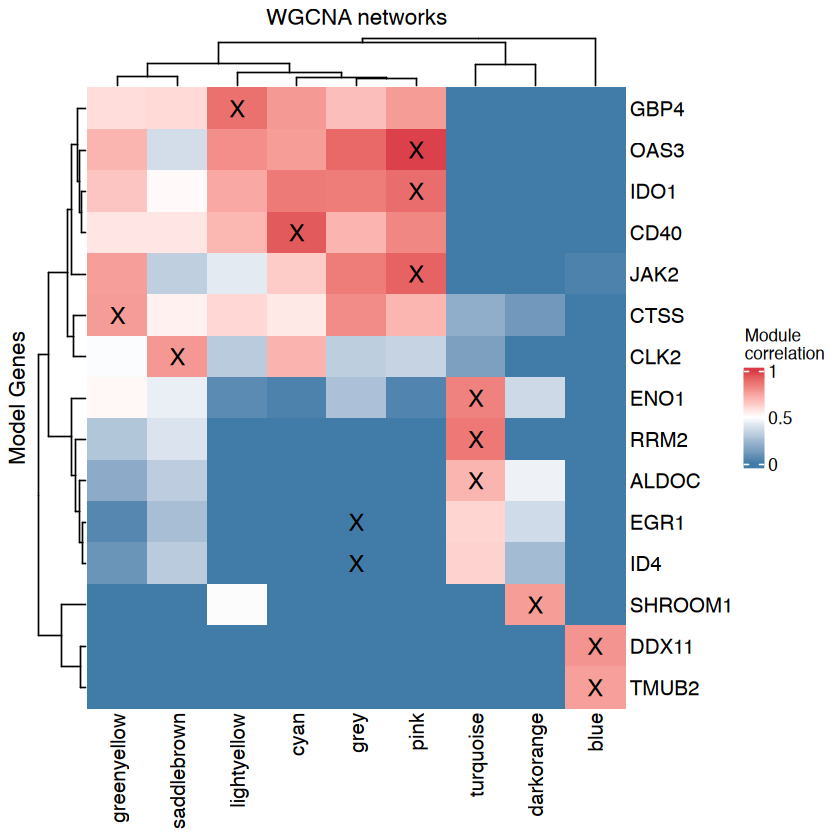

In [199]:
# Evaluate Module membership
#seurat_list[[2]]@misc$First$datExpr
sc_MM = cor(seurat_list[[num_use]]@misc$hdWGCNA$datExpr, as.data.frame(seurat_list[[num_use]]@misc$hdWGCNA$wgcna_net$multiMEs), use = "p")
use_gene_list = intersect(rownames(sc_MM), gene_list)
message("\nAvailable Genes:", use_gene_list)
sc_MM[1:2,1:4]
sc_MM_p = corPvalueStudent(sc_MM, nSamples = nrow(seurat_list[[num_use]]@misc$hdWGCNA$datExpr))
sc_MM <- as.data.frame(sc_MM[use_gene_list, , drop = FALSE])


# Add Gene column
sc_MM$Gene <- rownames(sc_MM)
# Convert to long format manually (tidyverse isn't installing)
sc_MM_long <- data.frame(
  Gene   = rep(sc_MM$Gene, times = ncol(sc_MM) - 1),
  Module = rep(colnames(sc_MM)[colnames(sc_MM) != "Gene"],
               each = nrow(sc_MM)),
  MM     = as.vector(as.matrix(sc_MM[, colnames(sc_MM) != "Gene"]))
)
# Add p-values (same order as MM vector)
sc_MM_long$pval <- as.vector(sc_MM_p[use_gene_list, , drop = FALSE])
# have the modules not have the annoying first part
sc_MM_long$Module <- sub("hdWGCNA.data.ME", '', sc_MM_long$Module)

# only consdier modules from gene list
gene_module_df = seurat_list[[num_use]]@misc$hdWGCNA$wgcna_modules[seurat_list[[num_use]]@misc$hdWGCNA$wgcna_modules$gene_name %in% use_gene_list,]
gene_module_df
gene_modules = gene_module_df$module

mm_mat <- with(
  sc_MM_long[sc_MM_long$Module %in% gene_modules,],
  tapply(MM, list(Gene, Module), identity)
)
mm_mat <- as.matrix(mm_mat)
mm_mat[1:3,1:2]
library(ComplexHeatmap)
#install.packages("colorRamp2")
library(colorRamp2)
pdf(paste0("../plots/", CT, "_", time, "Cell_Module_Heatmap.pdf"), width = 5, height = 7)
ht = Heatmap(
  mm_mat,
  col = colorRamp2(c(0, 0.5, 1), c("#417ca8ff", "white", "#da3a46ff")),
  name = "Module\ncorrelation",
  row_title = "Model Genes",
  column_title = "WGCNA networks",
  cluster_rows = TRUE,
  cluster_columns = TRUE, 
  cell_fun = function(j, i, x, y, width, height, fill) {
    gene <- rownames(mm_mat)[i]
    module <- colnames(mm_mat)[j]
	gene_module = gene_module_df[gene_module_df$gene_name == gene,]$module
    if (!is.na(gene_module) &&
        gene_module == module) {

      grid.text(
        "X",
        x = x,
        y = y,
        gp = gpar(col = "black", fontsize = 14, fontface = "bold")
      )
    }
  }
)
print(ht)
dev.off()
print(ht)




#### Biologically annotate each module

In [200]:

module_GO_list = list()
for (gene_module in unique(gene_modules)) {
	genes_consider = seurat_list[[num_use]]@misc$hdWGCNA$wgcna_modules[seurat_list[[num_use]]@misc$hdWGCNA$wgcna_modules$module == gene_module,]$gene_name
	message(gene_module, length(genes_consider))
	module_GO_list[[gene_module]] = annotate_module_GO(genes_consider, rownames(seurat_list[[num_use]]@misc$hdWGCNA$wgcna_modules))
}

turquoise1132

1132

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

lightyellow115

115

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

greenyellow243

243

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

grey1769

1769

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

pink315

315

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

blue612

612

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

cyan150

150

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

saddlebrown55

55

'select()' returned 1:1 mapping between keys and

In [201]:
message(CT, " ", time)

Myeloid_APC Pre



In [ ]:
module_summary <- lapply(module_GO_list, function(x) {
  if (is.null(x) || nrow(x@result) == 0) return(NA)
  result <- x@result[grepl(paste(gene_list, collapse="|"), x@result$geneID),]
  #result <- x@result
  head(result[, c("Description", "p.adjust", "geneID")], 5)
})
module_summary

EOC_pre_list = c("grey"="adapt_immune_leukactiv", "turquoise"="TypeIIIfn_acidmetab", "yellow"="mix_actin_cellpolar", "green"="conntissue_GrowthFact", "black"="cellcycle")
EOC_post_list = c("grey"="mix_chrom", "yellow"="LymphApopt_TypeIIIfn", "brown"="RNA_process_Ribosome_JAKSTAT", "black"="muscle_RespCyclic", "red"="SaccMetab_EpithDiff")

CAF_post_list = c("turquoise"="Mit_proteasome_Ubiquit", "grey"="ChromDNArepair_ImmuneReceptor", "blue"="MHC_ETC", "brown"="Actin", "red"="diff_dvlpt")
CAF_pre_list = c("blue"="ATPMetab", "grey"="Metab_AdapImmune", "turquoise"="splicing", "brown"="diff_dvlpt")

Mes_pre_list = c("turquoise"="hypoxia_ERstress", "grey"="DNArep_glycerolipid", "yellow"="lysosome_dvlpt", "salmon"="T17_DNArep", "magenta"="apop_cytokine_reg", "blue"="Cellcycle")
Mes_post_list = c("grey"="DNArep_glycerolipid", "turquoise"="rRNA_MHC", "green"="ProteinTrans_IFN", "yellow"="Neuroblast_GrowthFac", "black"="Mix_Microtubule", "blue"="dvlpt", "red"="Mix_StimResponse")

Mac_post=c("purple"="Respiration", "grey"="DNAChromatin", "cyan"="MHC", "greenyellow"="Protfold_cytokine", "green"="Adhes_dvlpt", "pink"="virus", "turquoise"="ProteinUbiq", "black"="Mixture", "red"="Phagocyt_Transport", "tan"="Lymph_Activation")
Mac_pre=c("turquoise"="ADPmetab", "grey"="DNAChromatin", "blue"="ProteinUbiq_Apoptosis", "salmon"="virus")

T_pre = c("turquoise"="Respiration", "grey"="ECM_morphogenesis", "brown"="cellmotility_dvlpt_Tcellact")
T_post = c("blue"="Respiration", "grey"="ECM_morphogenesis", "green"="MHC", "turquoise"="Splicing", "yellow"="Translation_Bactresponse")

IL_post = c("brown"="Respiration", "grey"="ECM_dvlpt", "green"="Cytokine_TypeIIIFN", "black"="membrane", "turquoise"="Mitoc_NTbiosynthesis")
IL_pre = c("blue"="Respiration_Rib", "grey"="Mix_Macroauto", "yellow"="Neut_granulocyte", "greenyellow"="BactResponse", "black"="AAcat", "green"="Mix_tRNA", "turquoise"="NK_NKFB_Chromatin", "darkturquoise"="MitochFission")

B_pre = c("turquoise"="Respiration_Rib", "grey"="Mix_dvlpt", "black"="axon_WNT_ECM", "brown"="virus_MHC")
B_post = c("blue"="Respiration_Rib", "grey"="Mix_cilia_CAMet", "turquoise"="MHC_LymphAct_Cytokine")

MY_APC_pre = c("turqoise"="CAMet", "lightyellow"="ImmuneReceptorSignal", "greenyellow"="Actin_Inflammasome", "grey"="Mixture_dvlpt", "pink"="Virus_Cytokine_IFN", "blue"="Splicing", "cyan"="Growth", 
"saddlebrown"="NotchSignaling", "darkorange"="Mixture_Actin")
MY_APC_post = c("grey60"="Respiration", "grey"="Phosphatidylinositol_lipoprotein", "green"="MHC", "greenyellow"="DNAReplic_Viral", "brown"="SterolMetab_LymphLeuk", "tan"="GrowthFactor")

,Description,p.adjust,geneID
,<chr>,<dbl>,<chr>
GO:0006082,organic acid metabolic process,7.847788e-11,ACOT7/ENO1/SESN2/AKR1A1/ECHDC2/SCP2/SLC16A1/PHGDH/SLC27A3/MGST3/GLUL/PTGS2/BPNT1/EGLN1/ADI1/HK2/DBI/PNKD/ACSL3/CRTAP/GPX1/SUCLG2/NIT2/PCCB/MCCC1/QDPR/PPAT/SLC39A8/HADH/MGST2/ANKH/DHFR/PCBD2/GNPDA1/LTC4S/PPARD/MTHFD1L/ACAT2/MDH2/PDK4/AKR1B1/TBXAS1/FGFR1/HACD4/PLAA/GRHPR/FBP1/CRAT/PFKP/ECHDC3/ALOX5/PCBD1/P4HA1/GLUD1/LIPA/PGAM1/GOT1/OAT/UROS/ECHS1/LDHA/ARL2/GSTP1/NUDT8/UCP2/GAPDH/TPI1/SLC2A3/LDHB/PTGES3/SHMT2/LTA4H/ACADS/CRYL1/IRS2/HIF1A/MTHFD1/HEXA/FAH/IDH2/ECI1/ALDOA/BCKDK/PYCARD/GPT2/GOT2/GCSH/TP53/ALDOC/STAT5B/SCPEP1/GALK1/DCXR/FOXK2/ENOSF1/C3/TECR/ILVBL/GPI/APOC1/ETFB/SLC27A5/ACOT8/PFKL/COL6A1/COMT/MIF/MPST/SMS/HSD17B10/PGK1/IDH3G/RENBP
GO:0043436,oxoacid metabolic process,7.847788e-11,ACOT7/ENO1/SESN2/AKR1A1/ECHDC2/SCP2/SLC16A1/PHGDH/SLC27A3/MGST3/GLUL/PTGS2/BPNT1/EGLN1/ADI1/HK2/DBI/PNKD/ACSL3/CRTAP/GPX1/SUCLG2/NIT2/PCCB/MCCC1/QDPR/PPAT/SLC39A8/HADH/MGST2/ANKH/DHFR/PCBD2/GNPDA1/LTC4S/PPARD/MTHFD1L/ACAT2/MDH2/PDK4/AKR1B1/TBXAS1/FGFR1/HACD4/PLAA/GRHPR/FBP1/CRAT/PFKP/ECHDC3/ALOX5/PCBD1/P4HA1/GLUD1/LIPA/PGAM1/GOT1/OAT/UROS/ECHS1/LDHA/ARL2/GSTP1/NUDT8/UCP2/GAPDH/TPI1/SLC2A3/LDHB/PTGES3/SHMT2/LTA4H/ACADS/CRYL1/IRS2/HIF1A/MTHFD1/HEXA/FAH/IDH2/ECI1/ALDOA/BCKDK/PYCARD/GPT2/GOT2/GCSH/TP53/ALDOC/SCPEP1/GALK1/DCXR/FOXK2/ENOSF1/C3/TECR/ILVBL/GPI/APOC1/ETFB/SLC27A5/ACOT8/PFKL/COL6A1/COMT/MIF/MPST/SMS/HSD17B10/PGK1/IDH3G/RENBP
GO:0019752,carboxylic acid metabolic process,1.841790e-10,ACOT7/ENO1/SESN2/AKR1A1/ECHDC2/SCP2/SLC16A1/PHGDH/SLC27A3/MGST3/GLUL/PTGS2/EGLN1/ADI1/HK2/DBI/PNKD/ACSL3/CRTAP/GPX1/SUCLG2/NIT2/PCCB/MCCC1/QDPR/PPAT/SLC39A8/HADH/MGST2/DHFR/PCBD2/GNPDA1/LTC4S/PPARD/MTHFD1L/ACAT2/MDH2/PDK4/AKR1B1/TBXAS1/HACD4/PLAA/GRHPR/FBP1/CRAT/PFKP/ECHDC3/ALOX5/PCBD1/P4HA1/GLUD1/LIPA/PGAM1/GOT1/OAT/UROS/ECHS1/LDHA/ARL2/GSTP1/NUDT8/UCP2/GAPDH/TPI1/SLC2A3/LDHB/PTGES3/SHMT2/LTA4H/ACADS/CRYL1/IRS2/HIF1A/MTHFD1/HEXA/FAH/IDH2/ECI1/ALDOA/BCKDK/PYCARD/GPT2/GOT2/GCSH/TP53/ALDOC/SCPEP1/GALK1/DCXR/FOXK2/ENOSF1/C3/TECR/ILVBL/GPI/APOC1/ETFB/SLC27A5/ACOT8/PFKL/COL6A1/COMT/MIF/MPST/SMS/HSD17B10/PGK1/IDH3G/RENBP
GO:0044282,small molecule catabolic process,9.236061e-09,ACOT7/ENO1/SESN2/AKR1A1/ECHDC2/SCP2/SLC16A1/GLUL/GALM/HK2/PNKD/GLB1/PCCB/MCCC1/QDPR/HADH/GNPDA1/PPARD/ACAT2/NUDT1/UPP1/CRAT/PFKP/NUDT5/GLUD1/PGAM1/GOT1/OAT/ECHS1/NUDT8/TPI1/ACADS/CRYL1/IRS2/PNP/HEXA/FAH/ECI1/BCKDK/GPT2/GOT2/GCSH/TP53/GALK1/DCXR/FOXK2/ENOSF1/ILVBL/ETFB/ACOT8/PFKL/MPST/APOBEC3C/HSD17B10/PGK1/RENBP
GO:0006091,generation of precursor metabolites and energy,6.025542e-08,ENO1/SDHB/AKR7A2/UQCRH/PHGDH/SDHC/OPN3/HK2/SUCLG1/RPIA/CHCHD5/CHCHD4/UQCRC1/RHOA/TKT/SUCLG2/NDUFB5/QDPR/PGM2/NDUFS6/CCNB1/COX7C/UQCRQ/CXXC5/NDUFA2/GNPDA1/TNF/UQCC2/PPARD/SDHAF4/CYCS/CHCHD2/MDH2/AKR1B1/NDUFB2/NDUFB9/CYC1/FBP1/SURF1/PFKP/LIPA/PGAM1/NDUFB8/LDHA/COX8A/ARL2/NDUFV1/NDUFS8/UCP2/GAPDH/TPI1/PHB2/BLOC1S1/PTGES3/SHMT2/IRS2/HIF1A/NDUFB1/IDH2/TRAP1/UQCRC2/ALDOA/TP53/ALDOC/GALK1/GAA/FOXK2/CYB5A/NDUFS7/NDUFA11/GPI/GYS1/ETFB/PFKL/COL6A1/COMT/CHCHD10/NDUFA6/PGK1/IDH3G
,Description,p.adjust,geneID
,<chr>,<dbl>,<chr>
GO:0009617,response to bacterium,0.6298780,GBP4/CD86/TNIP2/AHR/WASL/LYN/CASP7/IL10RA
GO:0042832,defense response to protozoan,0.6298780,GBP4


In [50]:

### Perform GO enrichment
#BiocManager::install("fgsea", version="3.20")
annotate_module_GO <- function(genes, universe) {
  
  message(length(genes))
  
  eg <- AnnotationDbi::mapIds(
    org.Hs.eg.db::org.Hs.eg.db,
    keys = genes,
    keytype = "SYMBOL",
    column = "ENTREZID",
    multiVals = "first"
  )
  eg <- na.omit(eg)
  
  universe_eg <- AnnotationDbi::mapIds(
    org.Hs.eg.db::org.Hs.eg.db,
    keys = universe,
    keytype = "SYMBOL",
    column = "ENTREZID",
    multiVals = "first"
  )
  universe_eg <- na.omit(universe_eg)
  
  clusterProfiler::enrichGO(
    gene = eg,
    universe = universe_eg,
    OrgDb = org.Hs.eg.db::org.Hs.eg.db,
    ont = "BP",
    pAdjustMethod = "BH",
    readable = TRUE
  )
}

